# Graph Visualization Assignment

Loaded a real graph dataset, calculated basic network metrics, visualized the graph, and prepared material for a short presentation/video. Dataset was the Stanford SNAP "email-Eu-core"

- Nodes represent members of a large European research institution. A directed edge `(u, v)` exists when person `u` sent person `v` at least one email. The full dataset contains 1,005 nodes and 25,571 directed edges.
- For path analysis we convert the network to an undirected graph which lets us study whether two people are connected no matter which person initiated the email contact.
-Diameter is apparently only defined for a connected graph, so we calculate it on the largest connected component.

https://snap.stanford.edu/data/email-Eu-core.html

In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("NetworkX version:", nx.__version__)

NetworkX version: 3.6.1


## Download and load the graph

The SNAP file is actually an edge list so each row has a source node and destination node.

In [2]:
#Download
!wget -q https://snap.stanford.edu/data/email-Eu-core.txt.gz -O email-Eu-core.txt.gz

#Load as a directed graph
G_directed = nx.read_edgelist(
    "email-Eu-core.txt.gz",
    create_using=nx.DiGraph(),
    nodetype=int
)

print("Directed graph")
print("Nodes:", G_directed.number_of_nodes())
print("Edges:", G_directed.number_of_edges())

Directed graph
Nodes: 1005
Edges: 25571


In [3]:
G = G_directed.to_undirected()

print("Undirected graph")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Connected components:", nx.number_connected_components(G))

Undirected graph
Nodes: 1005
Edges: 16706
Connected components: 20


The original data was directed because emails have a sender and receiver. This doesn't matter for our purposes because we just want to see the communications that are present. Converting to an undirected graph also makes the interpretation of shortest paths and diameter easier to observe.

## Graph analysis

We will calculate: Diameter defined as the greatest shortest path distance between any two nodes in the connected network. The average clustering coefficient defined as the average tendency for a node's neighbors to also be connected. Degree centrality defined as nodes with the largest number of direct connections relative to the maximum connections possible. Finally, average shortest path length is the average number of steps needed to travel between two nodes in the connected network.

In [4]:
#Diameter requires a connected graph and we use the largest connected component (LCC).
largest_cc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc_nodes).copy()

print("Largest connected component")
print("Nodes:", G_lcc.number_of_nodes())
print("Edges:", G_lcc.number_of_edges())

Largest connected component
Nodes: 986
Edges: 16687


In [5]:
#Network metrics
diameter = nx.diameter(G_lcc)
avg_clustering = nx.average_clustering(G_lcc)
avg_shortest_path = nx.average_shortest_path_length(G_lcc)
density = nx.density(G_lcc)

print(f"Diameter: {diameter}")
print(f"Average clustering coefficient: {avg_clustering:.4f}")
print(f"Average shortest-path length: {avg_shortest_path:.4f}")
print(f"Density: {density:.4f}")

Diameter: 7
Average clustering coefficient: 0.4071
Average shortest-path length: 2.5869
Density: 0.0344


## Degree centrality

Degree centrality measures how directly connected each node is. In this email network a node with high degree centrality communicates with many other people in the institution. It is very likely in this data people may not be too distantly connected.

In [6]:
degree_centrality = nx.degree_centrality(G_lcc)

centrality_df = (
    pd.DataFrame(
        degree_centrality.items(),
        columns=["Node", "Degree_Centrality"]
    )
    .sort_values("Degree_Centrality", ascending=False)
    .reset_index(drop=True)
)

centrality_df["Degree"] = centrality_df["Node"].map(dict(G_lcc.degree()))

print("Top 10 nodes by degree centrality")
display(centrality_df.head(10))

Top 10 nodes by degree centrality


,Node,Degree_Centrality,Degree
0,160,0.352284,347
1,121,0.237563,234
2,82,0.236548,233
3,107,0.224365,221
4,86,0.221320,218
5,62,0.219289,216
6,434,0.187817,185
7,13,0.182741,180
8,166,0.179695,177
9,183,0.175635,173


## Degree distribution

This plot shows how common different node degrees are.

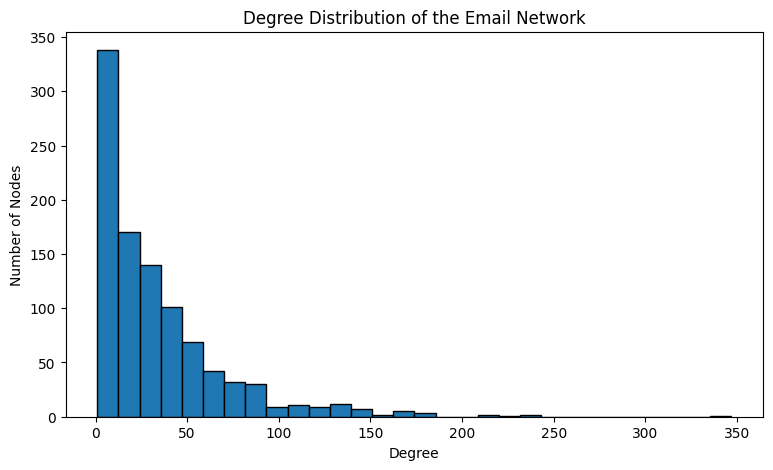

In [7]:
degrees = [degree for _, degree in G_lcc.degree()]

plt.figure(figsize=(9, 5))
plt.hist(degrees, bins=30, edgecolor="black")
plt.title("Degree Distribution of the Email Network")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.show()

## Network visualization

Plotting all nodes and thousands of edges creates a busy looking image. By suggestion i decided to visualize the 75 nodes with the highest degree.


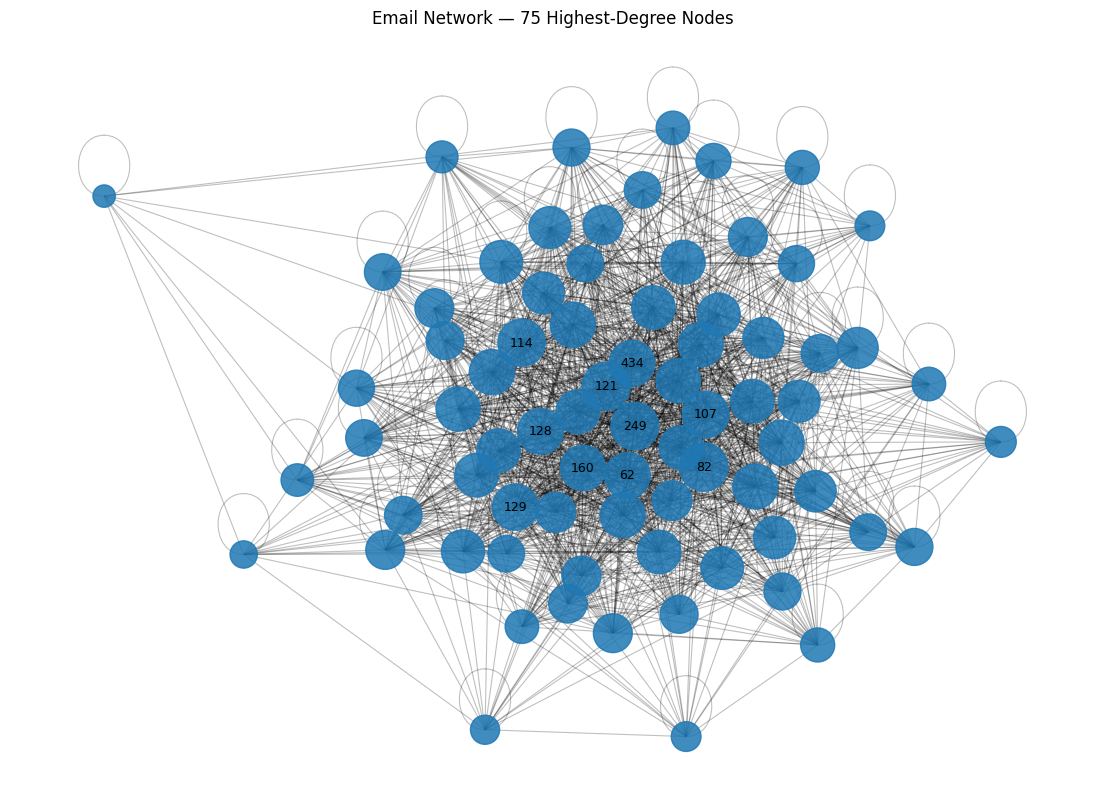

In [8]:
#75 highest-degree nodes
top_nodes = [
    node for node, degree
    in sorted(G_lcc.degree(), key=lambda x: x[1], reverse=True)[:75]
]

G_vis = G_lcc.subgraph(top_nodes).copy()

#Force directed layout
pos = nx.spring_layout(G_vis, seed=42, k=0.45)

node_sizes = [80 + 18 * G_vis.degree(n) for n in G_vis.nodes()]

plt.figure(figsize=(14, 10))
nx.draw_networkx_edges(
    G_vis,
    pos,
    alpha=0.25,
    width=0.8
)
nx.draw_networkx_nodes(
    G_vis,
    pos,
    node_size=node_sizes,
    alpha=0.85
)

#Only the 10 highest degree nodes
top_10 = sorted(G_vis.degree(), key=lambda x: x[1], reverse=True)[:10]
labels = {node: str(node) for node, _ in top_10}

nx.draw_networkx_labels(
    G_vis,
    pos,
    labels=labels,
    font_size=9
)

plt.title("Email Network — 75 Highest-Degree Nodes")
plt.axis("off")
plt.show()

## Visualization interpretation

The force directed layout places heavily interconnected nodes closer together. Larger nodes have higher degree, so they can be interpreted as communication hubs within this subset. Dense areas of the visualization suggest groups of members who communicate with many of the same people. The visualization is intentionally limited to 75 high degree nodes because plotting the entire network would make individual relationships difficult to see.

# Summary

Analysis of the largest connected component showed a diameter of 7 and an average shortest path length of about 2.59. This tells us that the network is very tight with members typically separated by less than three edges, and even the most distant pairs are actually separated by just seven.

The average clustering coefficient was 0.407 which suggests a lot of interconnectedness. I see this as individuals connected to the same person are also extremely likely to have connections with one another. This pattern is reasonable for an organizational email network where people likely work in departments and groups. Network density was 0.0344 meaning that approximately 3.44% of all theoretically possible undirected connections were present. Node 160 had the highest degree with 347 direct connections and a degree centrality of approximately 0.352. Results tell us this is a sparse network with dense connected local groups and a small number of highly connected nodes.